In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
clean_df = pd.read_csv('credit_risk_cleaned.csv')

In [4]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
clean_df['loan_status'].unique()

array([0, 1])

In [6]:
clean_df['loan_status'].value_counts()

loan_status
0    25467
1     7107
Name: count, dtype: int64

In [7]:
clean_df['loan_status'].value_counts(normalize=True).round(3)

loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64

In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

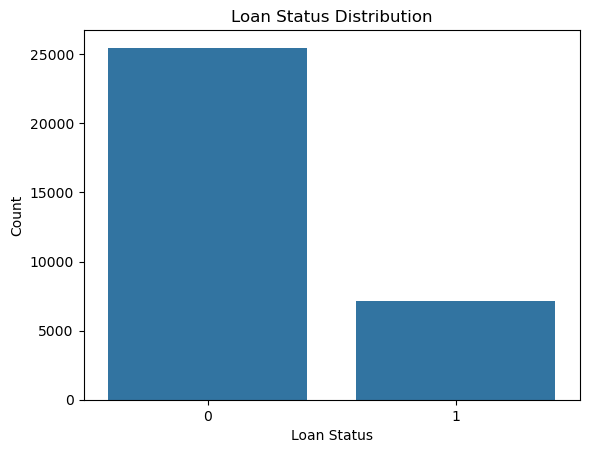

In [10]:
sns.countplot(x='loan_status', data=clean_df)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

## Target Variable Summary

The target variable is `loan_status`.

This variable has two values:
- 0: lower-risk / non-default group
- 1: higher-risk / default group

The distribution shows the overall share of each loan outcome group.
This target variable will be used for future credit risk analysis.

## Section 1: Income vs Loan Status

In [11]:
clean_df.groupby('loan_status')['person_income'].mean()

loan_status
0    70554.030628
1    49124.262839
Name: person_income, dtype: float64

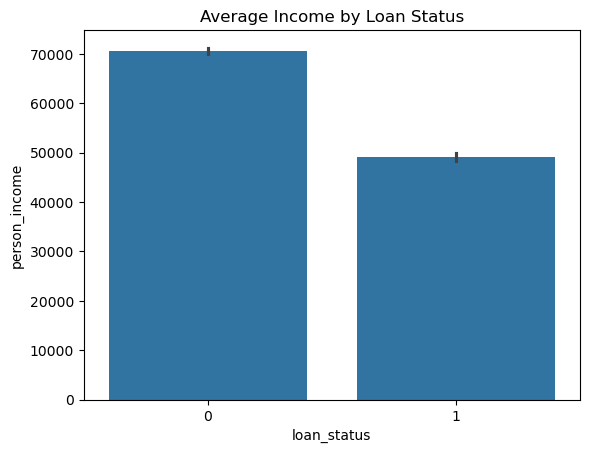

In [12]:
sns.barplot(x='loan_status', y='person_income', data=clean_df)
plt.title('Average Income by Loan Status')
plt.show()

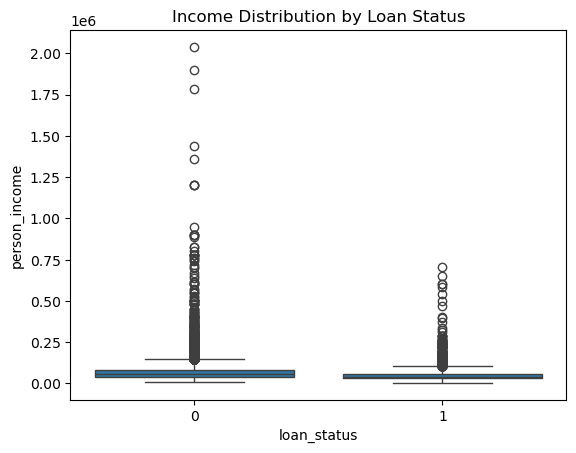

In [13]:
sns.boxplot(x='loan_status', y='person_income', data=clean_df)
plt.title('Income Distribution by Loan Status')
plt.show()

### Insight

- Borrowers with different loan outcomes show different income levels.
- This suggests that income may be related to credit risk.

In [14]:
clean_df.groupby('loan_status')['loan_int_rate'].mean()

loan_status
0    10.489643
1    12.872199
Name: loan_int_rate, dtype: float64

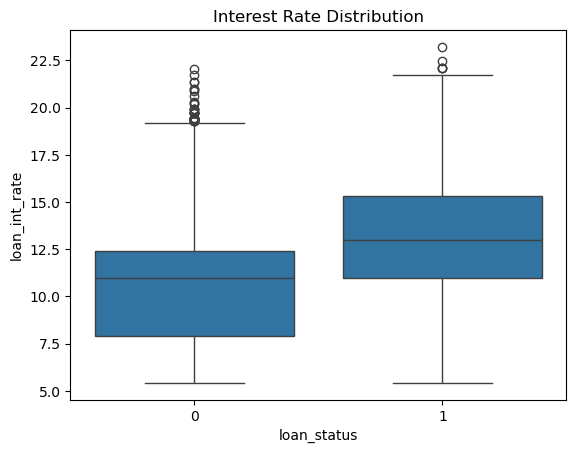

In [15]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=clean_df)
plt.title('Interest Rate Distribution')
plt.show()

### Interest Rate Insight

- Borrowers with default history tend to have higher interest rates.
- Interest rate may be an important predictor of loan default risk.

In [16]:
clean_df.groupby('loan_status')['loan_amnt'].mean()

loan_status
0     9236.648408
1    10847.104967
Name: loan_amnt, dtype: float64

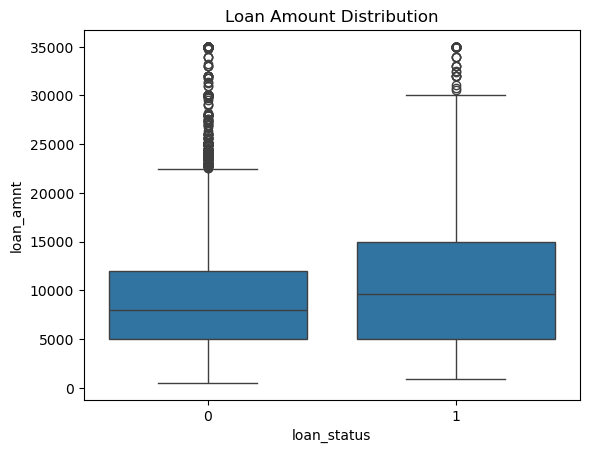

In [17]:
sns.boxplot(x='loan_status', y='loan_amnt', data=clean_df)
plt.title('Loan Amount Distribution')
plt.show()

### Loan Amount Insight

- Borrowers who defaulted tend to have slightly higher loan amounts on average.
- However, the distributions of default and non-default borrowers overlap heavily.
- Loan amount may be related to default risk, but it is probably not as strong a signal as interest rate.

## Section 2: Loan Burden Analysis

In [20]:
clean_df.groupby('loan_status')['loan_percent_income'].mean()

loan_status
0    0.148814
1    0.246841
Name: loan_percent_income, dtype: float64

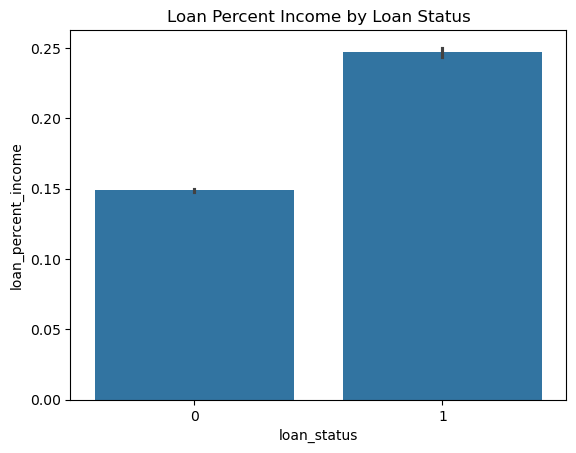

In [21]:
sns.barplot(x='loan_status', y='loan_percent_income', data=clean_df)
plt.title('Loan Percent Income by Loan Status')
plt.show()

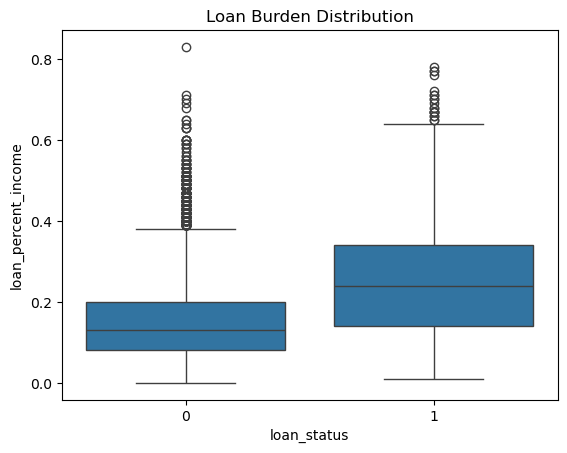

In [22]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=clean_df)
plt.title('Loan Burden Distribution')
plt.show()

### Insight

- Borrowers with higher loan-to-income ratios tend to have higher credit risk.
- This suggests that repayment burden is a key factor in loan default.

In [23]:
summary = clean_df.groupby('loan_status')[[
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income'
]].mean()

summary

,person_income,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,
0,70554.030628,9236.648408,10.489643,0.148814
1,49124.262839,10847.104967,12.872199,0.246841


In [24]:
summary.loc['difference'] = summary.loc[1] - summary.loc[0]
summary

,person_income,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,
0,70554.030628,9236.648408,10.489643,0.148814
1,49124.262839,10847.104967,12.872199,0.246841
difference,-21429.767788,1610.456559,2.382556,0.098027


## Final Numeric EDA Summary

- Borrowers who defaulted tend to have slightly lower income levels.
- Loan burden (loan_percent_income) shows a strong relationship with default risk.
- Higher interest rates are associated with higher borrower risk.
- Loan amount shows some differences between groups, but alone may not strongly explain default behavior.

These findings will guide the next stage of analysis, including categorical feature analysis and customer segmentation.